In [1]:
# Imports, env vars, logging/warning suppression

%env MUJOCO_GL=egl
# Pin to all 4 GPUs so jax.local_device_count() is deterministic (== 4).
# Must be set before `import jax`. The training config below assumes 4 devices.
%env CUDA_VISIBLE_DEVICES=0,1,2,3
import datetime
import functools
import os
import time
import warnings

import jax
import jax.numpy as jp
import matplotlib.pyplot as plt
import mediapy as media
import mujoco
import numpy as np
import warp as wp
from absl import logging
from brax.io import model
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from etils import epath
from mujoco_playground import registry, wrapper

import twmr  # noqa: F401 — registers TWMRLegFlat

wp.config.quiet = True
xla_flags = os.environ.get("XLA_FLAGS", "")
xla_flags += " --xla_gpu_triton_gemm_any=True"
os.environ["XLA_FLAGS"] = xla_flags
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
logging.set_verbosity(logging.WARNING)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

NUM_DEVICES = jax.local_device_count()

#(Commented Rn)
#media.set_ffmpeg("/bigdata/rhome/jbuh2025/Transformable-Leg-Wheel-Robot/.pixi/envs/default/bin/ffmpeg")
media.set_ffmpeg("/home/imeg2025/Transformable-Leg-Wheel-Robot/.pixi/envs/default/bin/ffmpeg")

print("jax:", jax.__version__, " |  device:", jax.default_backend(), " |  num_devices:", NUM_DEVICES)

env: MUJOCO_GL=egl
env: CUDA_VISIBLE_DEVICES=0,1,2,3
jax: 0.6.2  |  device: gpu  |  num_devices: 4


In [2]:
# ── Training config ───────────────────────────────────────────────────────────
# ENV_NAME             = "TWMRLegFlatRawTorques" 
ENV_NAME             = "TWMRLegTerr"  # With PD controller
SEED                 = 1

NUM_TIMESTEPS        = 2_000_000
EPISODE_LENGTH       = 250        # 5 s at ctrl_dt = 0.02 s/step
# Config assumes NUM_DEVICES == 4 (pinned via CUDA_VISIBLE_DEVICES in cell 1).
# Brax PPO has three divisibility constraints — all satisfied here:
#   1. NUM_ENVS % NUM_DEVICES == 0                  → 1024 % 4 == 0 ✓
#   2. BATCH_SIZE * NUM_MINIBATCHES % NUM_ENVS == 0 → 2048 % 1024 == 0 ✓
#   3. BATCH_SIZE % NUM_DEVICES == 0                → 256 % 4 == 0 ✓ (per-device minibatch reshape)
NUM_ENVS             = 1024
NUM_EVAL_ENVS        = 128
NUM_EVALS            = 20         # evals every 5 % → hits 5, 10, …, 100 %
UNROLL_LENGTH        = 10
BATCH_SIZE           = 256
NUM_MINIBATCHES      = 8
NUM_UPDATES_PER_BATCH = 8

LEARNING_RATE        = 5e-4
ENTROPY_COST         = 5e-3
DISCOUNTING          = 0.97
REWARD_SCALING       = 1.0
CLIPPING_EPSILON     = 0.3
MAX_GRAD_NORM        = 1.0
POLICY_HIDDEN        = (64, 64, 64)
VALUE_HIDDEN         = (64, 64, 64)
LOGDIR               = "logs"
# Render a video at these training percentages. (Made Change: TARGET_PCTS          = {5, 20, 50, 100} )
TARGET_PCTS          = set()
# ─────────────────────────────────────────────────────────────────────────────

In [3]:
# ── Logging directory ─────────────────────────────────────────────────────────
exp_name = f"{ENV_NAME}-{datetime.datetime.now().strftime('%Y%m%d-%H%M%S')}"
logdir   = epath.Path(LOGDIR).resolve() / exp_name
logdir.mkdir(parents=True, exist_ok=True)
ckpt_dir = logdir / "checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)
print(f"Logs: {logdir}")

# ── Environments ──────────────────────────────────────────────────────────────
# naconmax: GLOBAL contact budget for the Warp broadphase kernel that processes
#           all parallel worlds in one shot. Must be scaled with NUM_ENVS.
#           Observed peak: ~128 total across 1024 worlds → use 20× as headroom.
# njmax:    per-env constraint budget. Warp stacks it per-world via vmap, so
#           do NOT scale with NUM_ENVS. ~20-30 constraints/env; 500 has plenty.
NACONMAX_TRAIN = 40 * NUM_ENVS       # 40 960 global contacts for 1024 worlds (2× FLAT for TERR headroom)
NACONMAX_EVAL  = 40 * NUM_EVAL_ENVS  #  5 120 global contacts for  128 worlds
NJMAX          = 500                 # per-env (no NUM_ENVS scaling)

raw_env      = registry.load(ENV_NAME, config_overrides={
    "naconmax": NACONMAX_TRAIN,
    "njmax":    NJMAX,
})
raw_eval_env = registry.load(ENV_NAME, config_overrides={
    "naconmax": NACONMAX_EVAL,
    "njmax":    NJMAX,
})

# Per-env friction (geom_friction[ground,0]) lives at the mjx_model level,
# not in `state.info`. The wrapper builds a batched model with one friction
# value per env using this randomize fn; `_sample_domain_params` reads it
# back so `info` mirrors true physics.
#
# IMPORTANT — train env: brax PPO pmaps env.reset across all local devices and
# gives each device only `num_envs // num_devices` rngs. Our batched model must
# match that per-device size — otherwise the wrapper's vmap throws an
# inconsistent-axis-size error. (Brax's own wrap_for_training path does the
# same division at `brax/training/agents/ppo/train.py:99`; we replicate it
# because we set wrap_env=False.)
# Eval env: brax PPO forces `device_count=1` for eval (`train.py:766`), so it
# is NOT pmapped — the eval randomize_fn keeps the full NUM_EVAL_ENVS batch.
assert NUM_ENVS % NUM_DEVICES == 0, \
    f"NUM_ENVS={NUM_ENVS} not divisible by {NUM_DEVICES} devices"
randomize_train = functools.partial(
    twmr.twmr.domain_randomize_model,
    rng=jax.random.split(jax.random.PRNGKey(SEED), NUM_ENVS // NUM_DEVICES),
)
randomize_eval = functools.partial(
    twmr.twmr.domain_randomize_model,
    rng=jax.random.split(jax.random.PRNGKey(SEED + 1), NUM_EVAL_ENVS),
)

env = wrapper.wrap_for_brax_training(
    raw_env,
    episode_length=EPISODE_LENGTH,
    action_repeat=1,
    randomization_fn=randomize_train,
)

eval_env = wrapper.wrap_for_brax_training(
    raw_eval_env,
    episode_length=EPISODE_LENGTH,
    action_repeat=1,
    randomization_fn=randomize_eval,
)

print(f"action_size={raw_env.action_size}  obs_size={raw_env.observation_size}  num_devices={NUM_DEVICES}")

# Separate env instance used only for checkpoint video rendering (single-env,
# no DR — rendering should show neutral physics so behaviors look comparable).
_render_env     = registry.load(ENV_NAME)
_render_wrapped = wrapper.wrap_for_brax_training(
    _render_env, episode_length=EPISODE_LENGTH, action_repeat=1
)

# ── Action-space constants (from twmr.py) ─────────────────────────────────────
_WHEEL_MAX_SPEED = 8.0     # rad/s — action ±1 maps to ±8 (physical speed limit)
_LEG_CENTER      = 1.19    # rad   — midpoint of leg range
_LEG_HALF_RANGE  = 2.237   # rad   — half-width of leg range
_LEG_MIN         = -1.047  # rad
_LEG_MAX         =  3.427  # rad
_WHEEL_QVEL_IDX  = np.array([6, 10, 14, 18])  # wheel joint qvel indices (twmr.py)
_LEG_QPOS_IDX    = np.array([8, 12, 16, 20])  # leg joint qpos indices (twmr.py)


# ── Rollout rendering helper ──────────────────────────────────────────────────
def render_rollout(make_policy, params, outpath, label=""):
    """Run one deterministic episode, save mp4, and plot desired actions."""
    inference_fn = make_policy(params, deterministic=True)
    jit_infer    = jax.jit(inference_fn)

    rng_batch = jax.random.split(jax.random.PRNGKey(SEED + 100), 1)
    state     = jax.jit(_render_wrapped.reset)(rng_batch)

    def step_fn(carry, _):
        s, rng = carry
        rng, k = jax.random.split(rng)
        ks     = jax.random.split(k, 1)
        act    = jax.vmap(jit_infer)(s.obs, ks)[0]
        s      = _render_wrapped.step(s, act)
        return (s, rng), (s.data, act)

    _, (traj, actions) = jax.lax.scan(
        step_fn, (state, jax.random.PRNGKey(SEED)), None, length=EPISODE_LENGTH
    )
    traj.qpos.block_until_ready()

    # ── Extract numpy arrays for env 0 ───────────────────────────────────────
    qpos_np    = np.array(traj.qpos[:, 0])       # (T, nq)
    qvel_np    = np.array(traj.qvel[:, 0])        # (T, nv)
    actions_np = np.array(actions[:, 0])           # (T, 8)
    # Administered torques: mjx_env.step writes `data.ctrl = action`, and the
    # actuator order is [4 wheels, 4 legs], so ctrl[:, :4] are the wheel torques.
    ctrl_np         = np.array(traj.ctrl[:, 0])    # (T, nu)
    wheel_torque_np = ctrl_np[:, :4]               # (T, 4) N·m
    actual_wheel_vel = qvel_np[:, _WHEEL_QVEL_IDX] # (T, 4) rad/s — wheel joint vels
    actual_leg_pos   = qpos_np[:, _LEG_QPOS_IDX]   # (T, 4) rad   — leg joint pos

    # Compute max forward distance from the rollout trajectory
    x_positions = qpos_np[:, 0]
    max_x_dist  = float(x_positions.max() - x_positions[0])

    # ── Convert raw actions [-1, 1] to physical units ─────────────────────────
    desired_wheel_vel = actions_np[:, :4] * _WHEEL_MAX_SPEED             # rad/s
    desired_leg_pos   = _LEG_CENTER + actions_np[:, 4:] * _LEG_HALF_RANGE  # rad
    time_s = np.arange(EPISODE_LENGTH) * 0.02                             # seconds

    # ── Plot 1: Desired + actual wheel velocities (top) + administered torques (bottom)
    outpath_str = str(outpath)
    stem = outpath_str.rsplit(".", 1)[0]  # strip .mp4

    # Reuse one color per wheel index for both desired (solid) and actual (dashed).
    wheel_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][:4]

    fig_w, (ax_wv, ax_wt) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    for i in range(4):
        ax_wv.plot(time_s, desired_wheel_vel[:, i], color=wheel_colors[i],
                   linewidth=1.2, label=f"wheel_{i} desired")
        ax_wv.plot(time_s, actual_wheel_vel[:, i], color=wheel_colors[i],
                   linewidth=1.0, linestyle="--", label=f"wheel_{i} actual")
    ax_wv.set_ylabel("Wheel Velocity (rad/s)")
    ax_wv.set_title(f"Wheel Velocity (desired vs actual) — {label}" if label
                    else "Wheel Velocity (desired vs actual)")
    ax_wv.legend(loc="upper right", fontsize=7, ncol=2)
    ax_wv.grid(True, alpha=0.3)

    for i in range(4):
        ax_wt.plot(time_s, wheel_torque_np[:, i], color=wheel_colors[i],
                   linewidth=1.2, label=f"wheel_{i}")
    ax_wt.set_xlabel("Time (s)")
    ax_wt.set_ylabel("Administered Torque (N·m)")
    ax_wt.set_title(f"Administered Wheel Torque — {label}" if label else "Administered Wheel Torque")
    ax_wt.legend(loc="upper right", fontsize=8)
    ax_wt.grid(True, alpha=0.3)

    fig_w.tight_layout()
    wv_path = f"{stem}_wheel_vel.png"
    fig_w.savefig(wv_path, dpi=150)
    plt.show()
    print(f"  Saved: {wv_path}")

    # ── Plot 2: Desired + actual leg positions ────────────────────────────────
    # Same one-color-per-leg pattern as the wheel plot above: solid = desired
    # (from action[4:]), dashed = actual (from qpos at the leg-joint indices).
    leg_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"][:4]
    fig_l, ax_l = plt.subplots(figsize=(8, 4))
    for i in range(4):
        ax_l.plot(time_s, desired_leg_pos[:, i], color=leg_colors[i],
                  linewidth=1.2, label=f"leg_{i} desired")
        ax_l.plot(time_s, actual_leg_pos[:, i], color=leg_colors[i],
                  linewidth=1.0, linestyle="--", label=f"leg_{i} actual")
    ax_l.axhline(_LEG_MIN, color="grey", ls="--", lw=0.8, label="_LEG_MIN")
    ax_l.axhline(_LEG_CENTER, color="grey", ls="-.", lw=0.8, label="_LEG_CENTER")
    ax_l.axhline(_LEG_MAX, color="grey", ls="--", lw=0.8, label="_LEG_MAX")
    ax_l.set_xlabel("Time (s)")
    ax_l.set_ylabel("Position (rad)")
    ax_l.set_title(f"Leg Position (desired vs actual) — {label}" if label
                   else "Leg Position (desired vs actual)")
    ax_l.legend(loc="upper right", fontsize=7, ncol=2)
    ax_l.grid(True, alpha=0.3)
    fig_l.tight_layout()
    lp_path = f"{stem}_leg_pos.png"
    fig_l.savefig(lp_path, dpi=150)
    plt.show()
    print(f"  Saved: {lp_path}")

    # ── Render video ──────────────────────────────────────────────────────────
    mj_model   = _render_env.mj_model
    renderer   = mujoco.Renderer(mj_model, height=480, width=640)
    cam        = mujoco.MjvCamera()
    mujoco.mjv_defaultFreeCamera(mj_model, cam)
    cam.azimuth, cam.elevation, cam.distance = 135.0, -20.0, 1.5
    chassis_id = mujoco.mj_name2id(mj_model, mujoco.mjtObj.mjOBJ_BODY, "chassis")
    d = mujoco.MjData(mj_model)

    scene_option = mujoco.MjvOption()
    mujoco.mjv_defaultOption(scene_option)
    scene_option.flags[mujoco.mjtVisFlag.mjVIS_AUTOCONNECT]  = False
    scene_option.flags[mujoco.mjtVisFlag.mjVIS_CONTACTFORCE] = False
    scene_option.flags[mujoco.mjtVisFlag.mjVIS_PERTFORCE]    = False
    scene_option.flags[mujoco.mjtVisFlag.mjVIS_TRANSPARENT]  = False
    scene_option.geomgroup[3] = 0  # hide collision geoms (group 3) — kills z-fighting flicker

    frames = []
    for i in range(qpos_np.shape[0]):
        d.qpos[:] = qpos_np[i]
        d.qvel[:] = qvel_np[i]
        mujoco.mj_forward(mj_model, d)
        cam.lookat[:] = d.xpos[chassis_id]
        renderer.update_scene(d, camera=cam, scene_option=scene_option)
        frames.append(renderer.render())
    renderer.close()

    media.write_video(str(outpath), frames, fps=1.0 / _render_env.dt)
    media.show_video(frames, fps=1.0 / _render_env.dt)
    print(f"  Saved: {outpath}  |  max_dist={max_x_dist:.3f}m")
    return frames

Logs: /home/imeg2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegTerr-20260514-124751
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.
action_size=8  obs_size=38  num_devices=4


  T1 friction                [+0.700, +1.296]  target [+0.70, +1.30]  PASS
  T1 wheel_motor_strength    [+0.850, +1.149]  target [+0.85, +1.15]  PASS
  T1 leg_motor_strength      [+0.851, +1.150]  target [+0.85, +1.15]  PASS
  T2 friction                std=0.1725  expected=0.1732  |Δ|=0.4%  PASS
  T2 wheel_motor_strength    std=0.0841  expected=0.0866  |Δ|=2.9%  PASS
  T2 leg_motor_strength      std=0.0870  expected=0.0866  |Δ|=0.5%  PASS
  T3 friction                max drift over 200 steps = 0.00e+00  PASS
  T3 wheel_ms                max drift over 200 steps = 0.00e+00  PASS
  T3 leg_ms                  max drift over 200 steps = 0.00e+00  PASS
  T4 priv_obs slice matches info  max|Δ|=0.00e+00  PASS
  T5a wheel_motor_strength  mean|Δqvel|=0.5303  PASS
  T5a leg_motor_strength    mean|Δqvel|=0.1269  PASS
  T5b model.friction_scale    range [+0.700, +1.296]  std=0.1725/0.1732  |Δ|=0.4%  PASS
  T5b info vs model: friction max|Δ|=0.00e+00  PASS


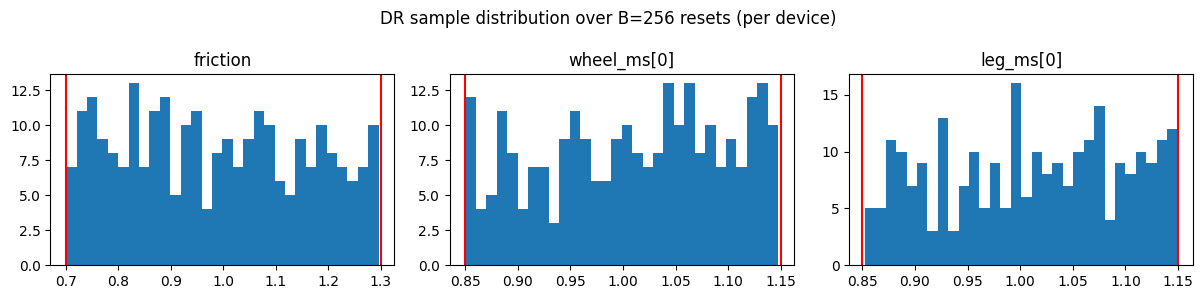

DR VERIFICATION DONE — all 3 randomized params are live in episodes.


In [4]:
# === DR VERIFICATION ====================================================
# Confirms every domain-randomized parameter actually affects an episode.
# Run after `env` is built; uses the WRAPPED env so per-env friction from
# `domain_randomize_model` is exercised end-to-end.
# Batch size MUST match the per-device size used to build env._mjx_model_v
# (the wrapper's vmap reset will reject a mismatched rng batch).

from twmr.networks import STUDENT_OBS_SIZE, PRIV_OBS_SIZE
from twmr.twmr import (
    _FRICTION_RANGE, _WHEEL_MOTOR_RANGE, _LEG_MOTOR_RANGE,
    _FLOOR_GEOM_ID,
)

B_VERIFY = NUM_ENVS // NUM_DEVICES
_keys = jax.random.split(jax.random.PRNGKey(0), B_VERIFY)
state0 = jax.jit(env.reset)(_keys)

# --- T1: sampled values lie inside the documented ranges ----------------
def _check_range(name, vals, lo, hi):
    v = np.asarray(vals).ravel()
    ok = (v.min() >= lo - 1e-6) and (v.max() <= hi + 1e-6)
    print(f"  T1 {name:<22s}  [{v.min():+.3f}, {v.max():+.3f}]  "
          f"target [{lo:+.2f}, {hi:+.2f}]  {'PASS' if ok else 'FAIL'}")
    assert ok, f"{name} out of range"

_check_range("friction",             state0.info["friction"],             *_FRICTION_RANGE)
_check_range("wheel_motor_strength", state0.info["wheel_motor_strength"], *_WHEEL_MOTOR_RANGE)
_check_range("leg_motor_strength",   state0.info["leg_motor_strength"],   *_LEG_MOTOR_RANGE)

# --- T2: per-uniform std matches (b-a)/sqrt(12) within 10% --------------
# Friction variation here comes from `domain_randomize_model` writing per-env
# values into mjx_model; `_sample_domain_params` recovers them so `info`
# mirrors the physics-level distribution. Motor strengths are still sampled
# directly inside the env's rng stream.
def _check_uniform_std(name, vals, lo, hi):
    expected = (hi - lo) / np.sqrt(12.0)
    got = float(np.std(np.asarray(vals).ravel()))
    rel = abs(got - expected) / expected
    ok = rel < 0.10
    print(f"  T2 {name:<22s}  std={got:.4f}  expected={expected:.4f}  "
          f"|Δ|={rel:.1%}  {'PASS' if ok else 'FAIL'}")
    assert ok, f"{name} std off"

_check_uniform_std("friction",             state0.info["friction"],             *_FRICTION_RANGE)
_check_uniform_std("wheel_motor_strength", state0.info["wheel_motor_strength"], *_WHEEL_MOTOR_RANGE)
_check_uniform_std("leg_motor_strength",   state0.info["leg_motor_strength"],   *_LEG_MOTOR_RANGE)

# --- T3: DR is constant across a 200-step rollout (sampled once at reset)
@jax.jit
def _rollout_check_const(state):
    def step(s, _):
        a = jp.zeros((B_VERIFY, raw_env.action_size))
        ns = env.step(s, a)
        return ns, (ns.info["friction"], ns.info["wheel_motor_strength"],
                    ns.info["leg_motor_strength"])
    _, hist = jax.lax.scan(step, state, None, length=200)
    return hist
_fric_h, _wms_h, _lms_h = _rollout_check_const(state0)
for _name, _h, _ref in [("friction", _fric_h, state0.info["friction"]),
                        ("wheel_ms", _wms_h, state0.info["wheel_motor_strength"]),
                        ("leg_ms",   _lms_h, state0.info["leg_motor_strength"])]:
    drift = float(jp.max(jp.abs(_h - _ref[None])))
    print(f"  T3 {_name:<22s}  max drift over 200 steps = {drift:.2e}  "
          f"{'PASS' if drift < 1e-6 else 'FAIL'}")
    assert drift < 1e-6

# --- T4: priv-obs slice equals info values (proves μ sees them) ---------
priv = state0.obs[:, STUDENT_OBS_SIZE:STUDENT_OBS_SIZE + PRIV_OBS_SIZE]
expected = jp.concatenate([
    state0.info["friction"][:, None],
    state0.info["motor_strengths"],
], axis=-1)
err = float(jp.max(jp.abs(priv - expected)))
print(f"  T4 priv_obs slice matches info  max|Δ|={err:.2e}  "
      f"{'PASS' if err < 1e-6 else 'FAIL'}")
assert err < 1e-6

# --- T5a: motor-strength A/B — info-driven; overwrite info in state -----
# Motor strengths enter physics via state.info inside step()'s torque code,
# so a clean A/B test is to replace info[field] on a frozen state, step, and
# measure |Δqvel| between the two clamp values. Use a small action magnitude
# for legs so the leg torque doesn't saturate at ±_LEG_TORQUE_LIMIT (which
# would clip 0.85× and 1.15× to the same value and produce a false zero).
def _make_runner(K):
    @jax.jit
    def _run(state, action):
        def step(s, _):
            a = jp.broadcast_to(action, (B_VERIFY, raw_env.action_size))
            return env.step(s, a), None
        sN, _ = jax.lax.scan(step, state, None, length=K)
        return sN.data.qvel
    return _run

def _ab_info_effect(field_name, low, high, action, K=20):
    runner = _make_runner(K)
    def _state_with(val):
        v = jp.asarray(val)
        if v.ndim == 0:
            v = jp.full(state0.info[field_name].shape, v)
        else:
            v = jp.broadcast_to(v, state0.info[field_name].shape)
        info = {**state0.info, field_name: v}
        ws, ls = info["wheel_motor_strength"], info["leg_motor_strength"]
        info = {**info, "motor_strengths": jp.concatenate([ws, ls], axis=-1)}
        return state0.replace(info=info)
    return float(jp.mean(jp.abs(runner(_state_with(low), action) -
                                runner(_state_with(high), action))))

_fwd       = jp.array([1.,  1.,  1.,  1.,  0.,   0.,   0.,   0.])
_leg_small = jp.array([0.,  0.,  0.,  0.,  0.1,  0.1,  0.1,  0.1])  # under leg-torque saturation
_zero      = jp.zeros(8)

_d_wms = _ab_info_effect("wheel_motor_strength", 0.85, 1.15, _fwd, K=20)
print(f"  T5a wheel_motor_strength  mean|Δqvel|={_d_wms:.4f}  "
      f"{'PASS' if _d_wms > 1e-3 else 'FAIL (phantom!)'}")
assert _d_wms > 1e-3, "wheel_motor_strength has no effect on dynamics"

_d_lms = _ab_info_effect("leg_motor_strength", 0.85, 1.15, _leg_small, K=20)
print(f"  T5a leg_motor_strength    mean|Δqvel|={_d_lms:.4f}  "
      f"{'PASS' if _d_lms > 1e-3 else 'FAIL (phantom — try a smaller action magnitude)'}")
assert _d_lms > 1e-3, "leg_motor_strength has no effect on dynamics"

# --- T5b: friction — model-driven; inspect the batched model ------------
# Friction lives in mjx_model.geom_friction (per-env after `domain_randomize_model`)
# and is *baked into* every physics step automatically by the wrapper's vmap
# — there's no info-side scaling we can A/B-test. The cleanest proof that it
# is live is to look at the batched model itself and confirm it varies across
# envs in the expected range. T2 already proved `info` mirrors this value, so
# if the model carries per-env variation, physics consumes it.
_mv = env._mjx_model_v
_geom_fric = np.asarray(_mv.geom_friction[:, _FLOOR_GEOM_ID, 0])
_nom_fric = raw_env._nominal_floor_friction
_fric_scale_from_model = _geom_fric / _nom_fric

def _check_batched(name, vals, lo, hi):
    in_range = (vals.min() >= lo - 1e-6) and (vals.max() <= hi + 1e-6)
    expected_std = (hi - lo) / np.sqrt(12.0)
    got_std = float(np.std(vals))
    rel = abs(got_std - expected_std) / expected_std
    ok = in_range and rel < 0.10
    print(f"  T5b {name:<22s}  range [{vals.min():+.3f}, {vals.max():+.3f}]  "
          f"std={got_std:.4f}/{expected_std:.4f}  |Δ|={rel:.1%}  "
          f"{'PASS' if ok else 'FAIL'}")
    assert ok, f"{name} not properly batched in mjx_model"

_check_batched("model.friction_scale", _fric_scale_from_model, *_FRICTION_RANGE)

# Final sanity: model-derived friction == values shown in info (within fp eps).
_info_fric  = np.asarray(state0.info["friction"])
_err_fric  = float(np.max(np.abs(_fric_scale_from_model - _info_fric)))
print(f"  T5b info vs model: friction max|Δ|={_err_fric:.2e}  "
      f"{'PASS' if _err_fric < 1e-4 else 'FAIL'}")
assert _err_fric < 1e-4

# --- T6: histograms (visual sanity) -------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (_name, _v, _r) in zip(axes, [
    ("friction",    state0.info["friction"],                       _FRICTION_RANGE),
    ("wheel_ms[0]", state0.info["wheel_motor_strength"][:, 0],     _WHEEL_MOTOR_RANGE),
    ("leg_ms[0]",   state0.info["leg_motor_strength"][:, 0],       _LEG_MOTOR_RANGE),
]):
    ax.hist(np.asarray(_v).ravel(), bins=30)
    ax.axvline(_r[0], color="r"); ax.axvline(_r[1], color="r")
    ax.set_title(_name)
fig.suptitle(f"DR sample distribution over B={B_VERIFY} resets (per device)")
fig.tight_layout(); plt.show()
print("DR VERIFICATION DONE — all 3 randomized params are live in episodes.")
# === END DR VERIFICATION ================================================


In [5]:
from twmr.networks import (
    STUDENT_OBS_SIZE,
    PRIV_OBS_SIZE,
    TEACHER_OBS_SIZE,
    ENV_LATENT_SIZE,
    EnvFactorEncoder,
    TeacherPolicyNetwork,
    TeacherValueNetwork,
    TeacherPPONetworks,
    make_teacher_ppo_networks,
)

# Original inline definitions moved to packages/twmr/src/twmr/networks.py.
# To revert, uncomment the block below and remove the import above.
#
# from dataclasses import dataclass
# from typing import Sequence, Callable
#
# import jax
# import jax.numpy as jp
# from flax import linen as nn
#
# from brax.training import distribution
# from brax.training import networks
# from brax.training.agents.ppo import networks as ppo_networks
#
# # sizes from env
# STUDENT_OBS_SIZE = 29   # accel3 + gyro3 + gravity3 + leg_pos4 + wheel_vel4 + leg_vel4 + prev_action8
# PRIV_OBS_SIZE = 9       # friction1 + motor_strengths8
# TEACHER_OBS_SIZE = STUDENT_OBS_SIZE + PRIV_OBS_SIZE
# ENV_LATENT_SIZE = 8     # Phase 1 latent z_t
#
# # Env Factor Encoder μ
# class EnvFactorEncoder(nn.Module):
#     latent_dim: int = ENV_LATENT_SIZE
#
#     @nn.compact
#     def __call__(self, privileged_obs: jax.Array) -> jax.Array:
#         x = nn.Dense(64)(privileged_obs)
#         x = nn.tanh(x)
#         x = nn.Dense(64)(x)
#         x = nn.tanh(x)
#         z_t = nn.Dense(self.latent_dim)(x)
#         return z_t
#
# # ... (TeacherPolicyNetwork, TeacherValueNetwork, TeacherPPONetworks,
# # make_teacher_ppo_networks — see networks.py)

In [6]:
times           = [time.monotonic()]
saved_pcts      = set()
_sorted_targets = sorted(TARGET_PCTS)

# Collect (timestep, max_x_dist) at every eval for plotting
eval_steps_log: list[int]   = []
eval_dist_log:  list[float] = []
eval_reward_log: list[float] = []


def progress(num_steps, metrics):
    times.append(time.monotonic())
    reward   = metrics.get("eval/episode_reward", float("nan"))
    max_dist = metrics.get("eval/episode_max_x_dist", float("nan"))
    pct      = num_steps / NUM_TIMESTEPS * 100
    print(f"[{pct:5.1f}%] step={num_steps:>9,}  reward={reward:.4f}  max_dist={max_dist:.3f}m")
    eval_steps_log.append(num_steps)
    eval_dist_log.append(max_dist)
    eval_reward_log.append(reward)


def policy_params_fn(current_step, make_policy, params):
    # Save checkpoint on every callback firing (Brax fires this NUM_EVALS times).
    ckpt_path = ckpt_dir / f"ppo_step_{current_step:09d}"
    model.save_params(str(ckpt_path), params)

    pct = current_step / NUM_TIMESTEPS * 100
    for target in _sorted_targets:
        if pct >= target and target not in saved_pcts:
            saved_pcts.add(target)
            print(f"→ Rendering checkpoint at {pct:.1f}% (target ≥{target}%)…")
            outpath = logdir / f"rollout_{target:03d}pct.mp4"
            render_rollout(make_policy, params, outpath, label=f"{target}%")

network_factory = functools.partial(
    make_teacher_ppo_networks,
    policy_hidden_layer_sizes=POLICY_HIDDEN,
    value_hidden_layer_sizes=VALUE_HIDDEN,
    latent_dim=8,
)

train_fn = functools.partial(
    ppo.train,
    num_timesteps         = NUM_TIMESTEPS,
    num_evals             = NUM_EVALS,
    episode_length        = EPISODE_LENGTH,
    num_envs              = NUM_ENVS,
    unroll_length         = UNROLL_LENGTH,
    batch_size            = BATCH_SIZE,
    num_minibatches       = NUM_MINIBATCHES,
    num_updates_per_batch = NUM_UPDATES_PER_BATCH,
    learning_rate         = LEARNING_RATE,
    entropy_cost          = ENTROPY_COST,
    discounting           = DISCOUNTING,
    reward_scaling        = REWARD_SCALING,
    clipping_epsilon      = CLIPPING_EPSILON,
    max_grad_norm         = MAX_GRAD_NORM,
    normalize_observations= True,
    action_repeat         = 1,
    network_factory       = network_factory,
    wrap_env=False,
)
    

make_inference_fn, params, _ = train_fn(
    environment      = env,
    eval_env         = eval_env,
    progress_fn      = progress,
    policy_params_fn = policy_params_fn,
)

# Final checkpoint — load this in any downstream script (Phase 2, evals, etc.)
final_ckpt = ckpt_dir / "ppo_final"
model.save_params(str(final_ckpt), params)
print(f"\nSaved final checkpoint: {final_ckpt}")

print(f"\nJIT compile time : {times[1] - times[0]:.1f}s")
print(f"Total train time : {times[-1] - times[1]:.1f}s")

# # ── Plot: max forward distance vs training timesteps ─────────────────────────
# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(eval_steps_log/10e6, eval_dist_log, marker="o", markersize=4, linewidth=1.5)
# ax.set_xlabel("Training Timesteps (1e6)")
# ax.set_ylabel("Max Forward Distance (m)")
# ax.set_title("Max +x Distance Reached per Episode During Training")
# ax.grid(True, alpha=0.3)
# fig.tight_layout()
# fig.savefig(str(logdir / "max_x_dist_vs_steps.png"), dpi=150)
# plt.show()
# print(f"  Plot saved: {logdir / 'max_x_dist_vs_steps.png'}")

[  0.0%] step=        0  reward=-4.8973  max_dist=0.076m
[  6.1%] step=  122,880  reward=-2.6121  max_dist=0.114m
[ 12.3%] step=  245,760  reward=0.1166  max_dist=0.163m
[ 18.4%] step=  368,640  reward=0.8478  max_dist=0.172m
[ 24.6%] step=  491,520  reward=4.7085  max_dist=0.243m
[ 30.7%] step=  614,400  reward=6.3373  max_dist=0.271m
[ 36.9%] step=  737,280  reward=8.5165  max_dist=0.311m
[ 43.0%] step=  860,160  reward=8.3173  max_dist=0.304m
[ 49.2%] step=  983,040  reward=9.3769  max_dist=0.321m
[ 55.3%] step=1,105,920  reward=10.9166  max_dist=0.353m
[ 61.4%] step=1,228,800  reward=13.0265  max_dist=0.391m
[ 67.6%] step=1,351,680  reward=11.3343  max_dist=0.358m
[ 73.7%] step=1,474,560  reward=12.2392  max_dist=0.374m
[ 79.9%] step=1,597,440  reward=10.9978  max_dist=0.350m
[ 86.0%] step=1,720,320  reward=11.5933  max_dist=0.362m
[ 92.2%] step=1,843,200  reward=14.7020  max_dist=0.426m
[ 98.3%] step=1,966,080  reward=13.9073  max_dist=0.408m
[104.4%] step=2,088,960  reward=13.897

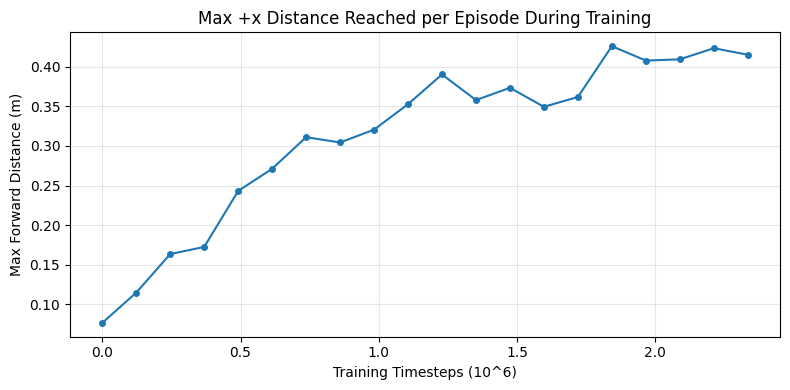

  Plot saved: /home/imeg2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegTerr-20260514-124751/max_x_dist_vs_steps.png
Rendering final rollout…


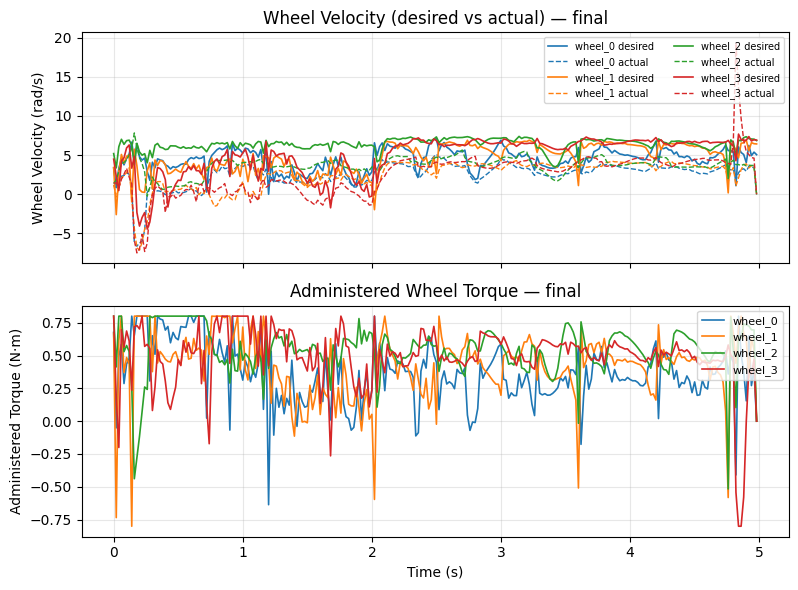

  Saved: /home/imeg2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegTerr-20260514-124751/rollout_final_wheel_vel.png


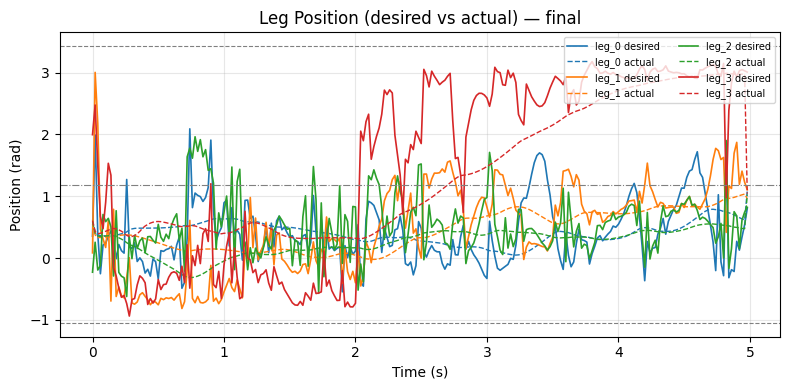

  Saved: /home/imeg2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegTerr-20260514-124751/rollout_final_leg_pos.png


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied



This browser does not support the video tag.


  Saved: /home/imeg2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegTerr-20260514-124751/rollout_final.mp4  |  max_dist=0.399m


This browser does not support the video tag.


In [7]:
# ── Plot: max forward distance vs training timesteps ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.array(eval_steps_log)/1e6, eval_dist_log, marker="o", markersize=4, linewidth=1.5)
ax.set_xlabel("Training Timesteps (10^6)")
ax.set_ylabel("Max Forward Distance (m)")
ax.set_title("Max +x Distance Reached per Episode During Training")
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(str(logdir / "max_x_dist_vs_steps.png"), dpi=150)
plt.show()
print(f"  Plot saved: {logdir / 'max_x_dist_vs_steps.png'}")

print("Rendering final rollout…")
frames = render_rollout(make_inference_fn, params, logdir / "rollout_final.mp4", label="final")
media.show_video(frames, fps=1.0 / _render_env.dt)

In [8]:
# ── M1 verification: checkpoint round-trip ────────────────────────────────────
# Load the just-saved final checkpoint, rebuild the inference function, run a
# deterministic rollout in the eval env, and compare mean episode reward to the
# last logged eval reward. Pass: within ±25% (single env vs 128-env mean).

from brax.training.acme import running_statistics

loaded_params = model.load_params(str(final_ckpt))
print(f"Loaded params from: {final_ckpt}")

# Rebuild the network with the SAME preprocessor used during training
# (normalize_observations=True → running_statistics.normalize). The loaded
# params' first element is the normalizer state, which is fed to apply().
network = network_factory(
    observation_size=raw_env.observation_size,
    action_size=raw_env.action_size,
    preprocess_observations_fn=running_statistics.normalize,
)
make_inference_fn_loaded = ppo_networks.make_inference_fn(network)
inference_fn_loaded = make_inference_fn_loaded(loaded_params, deterministic=True)
jit_infer = jax.jit(inference_fn_loaded)

# Run a single deterministic episode in the render env (1 env, EPISODE_LENGTH steps).
rng_batch = jax.random.split(jax.random.PRNGKey(SEED + 100), 1)
state = jax.jit(_render_wrapped.reset)(rng_batch)

def _step_loaded(carry, _):
    s, rng = carry
    rng, k = jax.random.split(rng)
    ks = jax.random.split(k, 1)
    act = jax.vmap(jit_infer)(s.obs, ks)[0]
    s = _render_wrapped.step(s, act)
    return (s, rng), s.reward

(state_final, _), rewards = jax.lax.scan(
    _step_loaded, (state, jax.random.PRNGKey(SEED)), None, length=EPISODE_LENGTH
)
ep_reward_loaded = float(jp.sum(rewards))
last_eval_reward = eval_reward_log[-1] if eval_reward_log else float("nan")

print(f"Loaded-checkpoint episode reward (1 env, deterministic): {ep_reward_loaded:.4f}")
print(f"Last training-eval reward (mean over {NUM_EVAL_ENVS} envs):   {last_eval_reward:.4f}")
if last_eval_reward == last_eval_reward:  # not nan
    rel = (ep_reward_loaded - last_eval_reward) / abs(last_eval_reward)
    print(f"Relative gap: {rel:+.1%}")
    # Soft acceptance: a single env is noisier than 128-env mean; allow ±25%.
    assert abs(rel) < 0.25, f"Round-trip reward gap too large: {rel:+.1%}"
    print("M1 PASS — checkpoint round-trip reproduces policy behavior.")


Loaded params from: /home/imeg2025/Transformable-Leg-Wheel-Robot/sandbox/logs/TWMRLegTerr-20260514-124751/checkpoints/ppo_final
Loaded-checkpoint episode reward (1 env, deterministic): 14.9094
Last training-eval reward (mean over 128 envs):   14.1708
Relative gap: +5.2%
M1 PASS — checkpoint round-trip reproduces policy behavior.


In [9]:
# ── M4 verification: Phase 2 inference path = standard path when fed true z ──
# Standard path  (a):  policy_module.apply(policy_params, full_obs)
#                       → splits internally → μ(priv) → mlp(student, z)
# Phase 2 path   (b):  z = μ(priv_obs) computed externally
#                       → policy_module.apply(policy_params, student_obs, z,
#                                             method=TeacherPolicyNetwork.apply_with_z)
# These must produce identical logits (and hence identical actions in
# deterministic mode). Tolerance: atol = 1e-5.

from twmr.networks import TeacherPolicyNetwork

# Re-instantiate the bare Flax modules (same hyperparams used by the network factory).
policy_module = TeacherPolicyNetwork(
    action_size=2 * raw_env.action_size,         # NormalTanhDistribution.param_size = 2 * event_size
    hidden_layer_sizes=POLICY_HIDDEN,
    latent_dim=ENV_LATENT_SIZE,
)
mu_module = EnvFactorEncoder(latent_dim=ENV_LATENT_SIZE)

# Pull the policy sub-tree out of the loaded params.  loaded_params is the tuple
# (normalizer_params, policy_params, value_params).
norm_params, policy_params, _value_params = loaded_params
mu_params = {"params": policy_params["params"]["EnvFactorEncoder_0"]}

# Generate a batch of pre-normalized obs (random — content doesn't matter for parity).
B = 64
rng = jax.random.PRNGKey(SEED + 99)
obs_full = jax.random.normal(rng, (B, raw_env.observation_size))

# Path (a): standard
logits_a = policy_module.apply(policy_params, obs_full)

# Path (b): externally compute z, then inject
student = obs_full[:, :STUDENT_OBS_SIZE]
priv    = obs_full[:, STUDENT_OBS_SIZE:STUDENT_OBS_SIZE + PRIV_OBS_SIZE]
z       = mu_module.apply(mu_params, priv)
logits_b = policy_module.apply(
    policy_params, student, z, method=TeacherPolicyNetwork.apply_with_z
)

max_diff = float(jp.max(jp.abs(logits_a - logits_b)))
print(f"Standard logits shape:    {logits_a.shape}")
print(f"apply_with_z logits shape: {logits_b.shape}")
print(f"max |standard − apply_with_z| = {max_diff:.2e}")

Standard logits shape:    (64, 16)
apply_with_z logits shape: (64, 16)
max |standard − apply_with_z| = 0.00e+00
